In [1]:
from misc_codes.general_settings import *
import re
import pandas as pd
import datetime
import matplotlib.pyplot as plt
%matplotlib inline

In [2]:
input_path = r"C:\Users\ccayno\OneDrive - Power Integrations\Wireless\FOD\8 - Default ATE, with Jitter, Cased, Not Clamped"
output_filename = "summary.xlsx"
output_path = input_path + '/' + output_filename

In [3]:
excel_files_list = GENERAL_FUNCTIONS().EXCEL_FILES_LIST(input_path)
excel_files_list = sorted(excel_files_list, key=lambda x: int(re.findall(r'\d+', x)[0]))
print(excel_files_list)
excel_file_list_without_ext = [os.path.splitext(file)[0] for file in excel_files_list]
selected_labels_ref = [file for file in excel_file_list_without_ext]
print(selected_labels_ref)

['90Vac, Default Casing with Spacer.xlsx', '100Vac, Default Casing with Spacer.xlsx', '115Vac, Default Casing with Spacer.xlsx', '120Vac, Default Casing with Spacer.xlsx', '132Vac, Default Casing with Spacer.xlsx']
['90Vac, Default Casing with Spacer', '100Vac, Default Casing with Spacer', '115Vac, Default Casing with Spacer', '120Vac, Default Casing with Spacer', '132Vac, Default Casing with Spacer']


In [4]:
def convert_timestamp_to_minutes(df):
    def convert_to_seconds(serial_number):
        if pd.isnull(serial_number):
            return None

        if isinstance(serial_number, int) or isinstance(serial_number, float):
            # Handle serial_number as a numeric value representing days
            seconds = serial_number * 24 * 60 * 60
            return int(seconds)  # Convert to seconds

        if isinstance(serial_number, datetime.datetime):
            # Handle serial_number as a datetime object
            time_delta = pd.to_timedelta(serial_number)
            seconds = time_delta.total_seconds()
            return int(seconds)  # Convert to seconds

        if isinstance(serial_number, datetime.time):
            # Handle serial_number as a time object
            serial_number_str = serial_number.strftime('%H:%M:%S')
            time_parts = serial_number_str.split(':')
            hours = int(time_parts[0])
            minutes = int(time_parts[1])
            seconds = int(time_parts[2])
            total_seconds = (hours * 60 * 60) + (minutes * 60) + seconds
            return total_seconds

        if isinstance(serial_number, str):
            # Handle serial_number as a string representation of a time value (e.g., '12:30')
            time_parts = serial_number.split(':')
            if len(time_parts) == 3:
                hours = int(time_parts[0])
                minutes = int(time_parts[1])
                seconds = int(time_parts[2])
                total_seconds = (hours * 60 * 60) + (minutes * 60) + seconds
                return total_seconds

        return None  # Invalid serial_number format

    def calculate_time_difference(row):
        if row['Time (s)'] >= 0:
            return row['Time (s)']
        else:
            return row['Time (s)'] + 24 * 60 * 60 if pd.notnull(row['Time (s)']) else None

    # Convert 'Timestamp' to seconds and create 'Time (s)' column
    df['Time (s)'] = df['Timestamp'].apply(convert_to_seconds)

    # Replace None values with a default value (e.g., 0)
    df['Time (s)'].fillna(0, inplace=True)

    # Calculate the interval as the cumulative sum of the differences between consecutive rows
    df['Time (s)'] = df['Time (s)'].diff().cumsum()

    # Handle day transition by adding 24 hours (24 * 60 * 60 seconds) to negative time differences
    df['Time (s)'] = df.apply(calculate_time_difference, axis=1)

    df.loc[0, 'Time (s)'] = 0  # Set the first row of 'Time (s)' column to 0

    # Convert 'Time (s)' to minutes and create 'Time (mins)' column
    df['Time (mins)'] = df['Time (s)'] / 60

    return df




def convert_hz_to_khz(df, column_name):
    # Convert Hz to kHz
    df['Fsw (kHz)'] = df[column_name] / 1000

    return df

def convert_CHS_to_SOC(df, column_name):
    # Convert CHS to SOC
    df['SOC (%)'] = df[column_name] * 100 / 256

    return df

def generate_comms_status(df):
    df['Comms Status'] = df['Toggle RMS'].apply(lambda x: 1 if x > 2 else 0)
    return df

def add_comms_count(df):
    df['COMMS_COUNT'] = df['TROUGH'] + df['PEAK']
    return df

In [5]:
dataframes = {}

for file in excel_files_list:
    print(f"Dataframe for {file} already captured.")
    file_path = os.path.join(input_path, file)
    df = pd.read_excel(file_path)

    # dataframe manipulation functions
    convert_timestamp_to_minutes(df)
    convert_hz_to_khz(df, column_name='V_antenna Frequency')
    # convert_CHS_to_SOC(df, column_name='CHS')
    # generate_comms_status(df)
    # add_comms_count(df)
    
    dataframes[file] = df

dfs = [dataframes[file] for file in excel_files_list]
selected_labels = selected_labels_ref

Dataframe for 90Vac, Default Casing with Spacer.xlsx already captured.
Dataframe for 100Vac, Default Casing with Spacer.xlsx already captured.
Dataframe for 115Vac, Default Casing with Spacer.xlsx already captured.
Dataframe for 120Vac, Default Casing with Spacer.xlsx already captured.
Dataframe for 132Vac, Default Casing with Spacer.xlsx already captured.


In [6]:
first_file_df = dataframes[excel_files_list[0]]
filtered_df = df[df['Time (mins)'] >= 10]
print(f"Min Vo = {filtered_df['Vo (V)'].min():.2f} V")
# print(f"{len(first_file_df['Vo (V)'])}")

# # CREATING HEADER_LIST
df_header_list = first_file_df.columns.tolist() # list of header
print(df_header_list)
# df_header = pd.DataFrame(columns = df_header_list)
# df_header.loc[len(df_header)] = df_header_list

# # CREATING SUMMARY FILE IF IT DOESN'T EXIST
# src = f"{os.getcwd()}/blank.xlsx"
# if not os.path.exists(output_path): shutil.copyfile(src, output_path)

# # LOADING WORKBOOK, THEN TRANSFERRING DF INTO SEPARATE SHEETS
# wb = load_workbook(output_path)
# for file in excel_file_list_without_ext:
#     if file == "90":
#         df_to_excel(wb, sheet_name=file, df=df_header, anchor='A1')
#         df_to_excel(wb, sheet_name=file, df=dataframes[f"{file}.xlsx"], anchor='A2')
# wb.save(output_path)


Min Vo = 22.03 V
['Timestamp', 'CC (A)', 'Vin (rms)', 'Freq (Hz)', 'Vac (VAC)', 'Iin (A)', 'Pin (W)', 'PF', 'THD (%)', 'Vo (V)', 'Io1 (A)', 'Po (W)', 'Vreg (%)', 'Ireg (%)', 'Eff (%)', 'Vbat Max', 'Vbat Peak to peak', 'Vbat RMS', 'V_antenna Max', 'V_antenna Peak to peak', 'V_antenna RMS', 'V_antenna Frequency', 'Ibat Max', 'Ibat Peak to peak', 'Ibat RMS', 'Time (s)', 'Time (mins)', 'Fsw (kHz)']


In [7]:
# from powi.equipment import *
# wb = load_workbook(output_path)
# chart_sheet = reset_chartsheet(wb)

# data_length = led_row[1] - led_row[0] - 2

# """ EFFICIENCY CHART """
# chart = create_scatter_chart(title="Efficiency (%)", style=2, x_title='Dimming Voltage (V)', y_title='Efficiency (%)',
#                     x_min_scale = 0, x_max_scale = 10, x_major_unit = 1, x_minor_unit = 0.5,
#                     y_min_scale = 0, y_max_scale = 95, y_major_unit = 10, y_minor_unit = 5)

# append_series(output_path, wb, file, x_anchor=f"D2", last_row_anchor=f"B40", series_title=f"test", chart=chart)

# save_chartsheet(chart_sheet, chart, chart_position=f"B1")

# wb.save(output_path)

In [8]:
def PLOT_DF_X_VS_YPRI_YSEC(dfs, x_col, y_col_pri, y_col_sec, ymax_pri, ymin_pri, ymax_sec, ymin_sec, xmax, xmin, y_color_pri, y_color_sec, selected_labels=None):
    fig, ax1 = plt.subplots()

    for i, df in enumerate(dfs):
        name_list = selected_labels_ref
        label = name_list[i]

        if selected_labels is None or label in selected_labels:
            # PRIMARY Y-AXIS
            ax1.plot(df[x_col], df[y_col_pri], label=label, color=y_color_pri)
            ax1.set_xlabel(x_col)
            ax1.set_ylabel(y_col_pri, color=y_color_pri)
            ax1.grid(True, linestyle=':', linewidth=0.5)
        
            ax1.set_ylim(bottom = ymin_pri)
            ax1.set_ylim(top = ymax_pri)
            ax1.set_xlim(left=xmin, right=xmax)

            # SECONDARY Y-AXIS
            ax2 = ax1.twinx()
            
            ax2.plot(df[x_col], df[y_col_sec], label=label, color=y_color_sec)
            ax2.set_ylabel(y_col_sec, color=y_color_sec)
            ax2.grid(True, linestyle=':', linewidth=0.5)
        
            ax2.set_ylim(bottom = ymin_sec)
            ax2.set_ylim(top = ymax_sec)
            ax2.set_xlim(left=xmin, right=xmax)
            
            plt.title(f'{y_col_pri} vs {y_col_sec} at {label}')
    
    plt.show()

In [9]:
def plot_data_for_fix_x_vs_ypri_and_ysec(dfs, selected_labels, x_col, xmax, xmin, plot_configs):
    for config in plot_configs:
        y_col_pri = config['y_col_pri']
        ymax_pri = config['ymax_pri']
        ymin_pri = config['ymin_pri']
        y_color_pri = config['y_color_pri']

        y_col_sec = config['y_col_sec']
        ymax_sec = config['ymax_sec']
        ymin_sec = config['ymin_sec']
        y_color_sec = config['y_color_sec']

        for label in selected_labels:
            label_list = [label]
            PLOT_DF_X_VS_YPRI_YSEC(dfs, x_col, y_col_pri, y_col_sec, ymax_pri, ymin_pri, ymax_sec, ymin_sec, xmax, xmin, y_color_pri, y_color_sec, label_list)

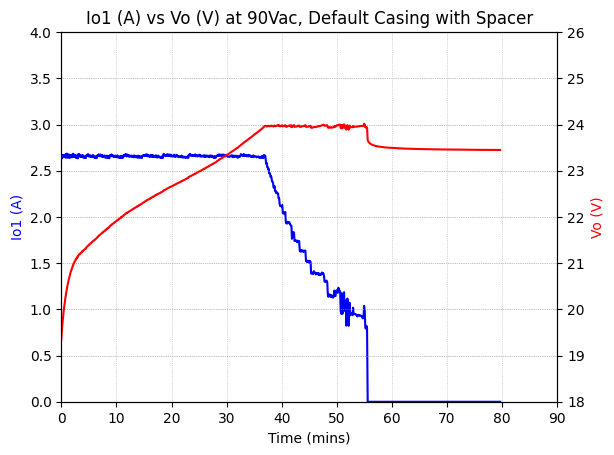

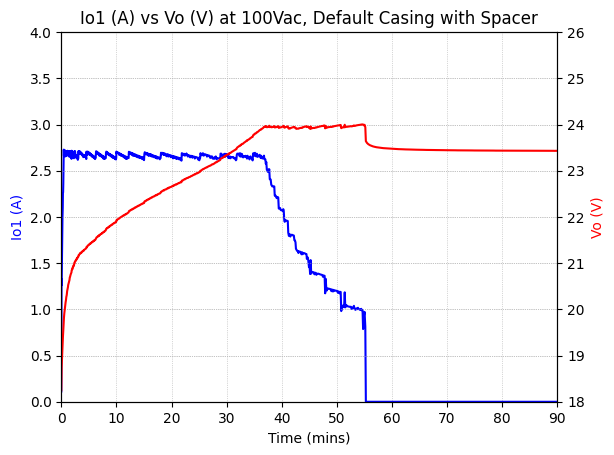

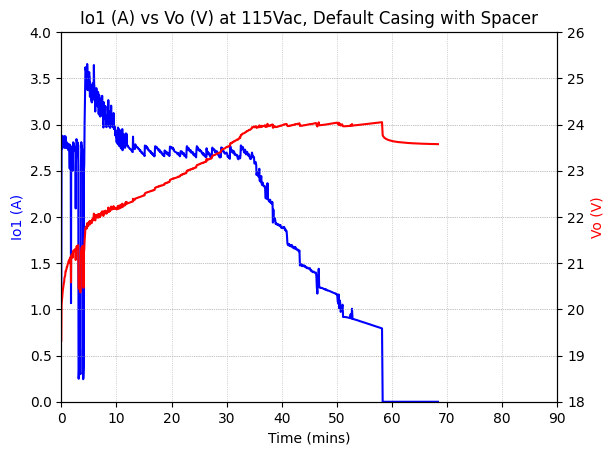

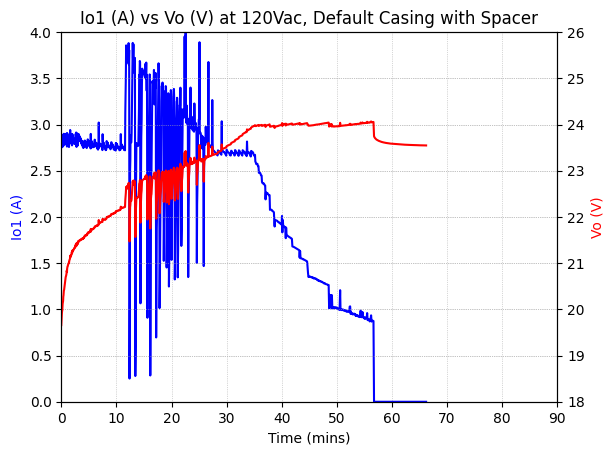

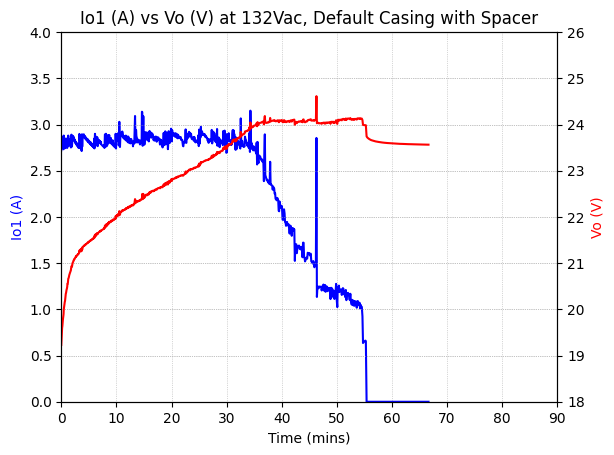

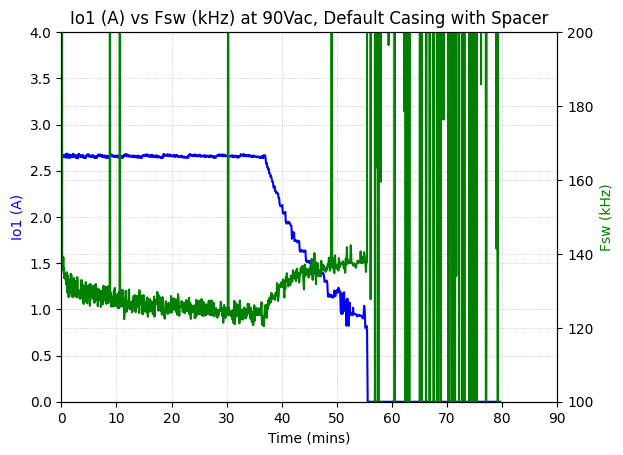

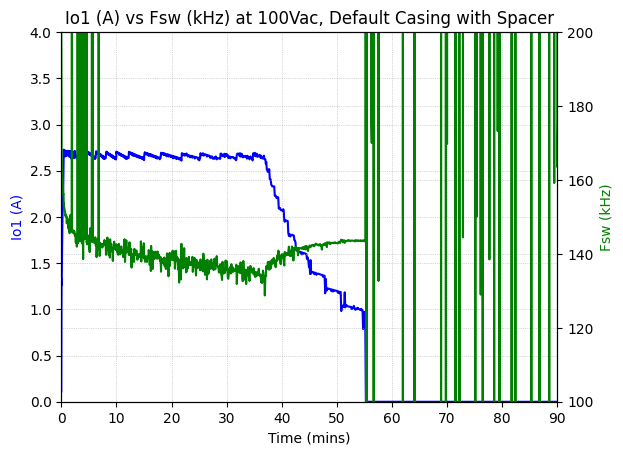

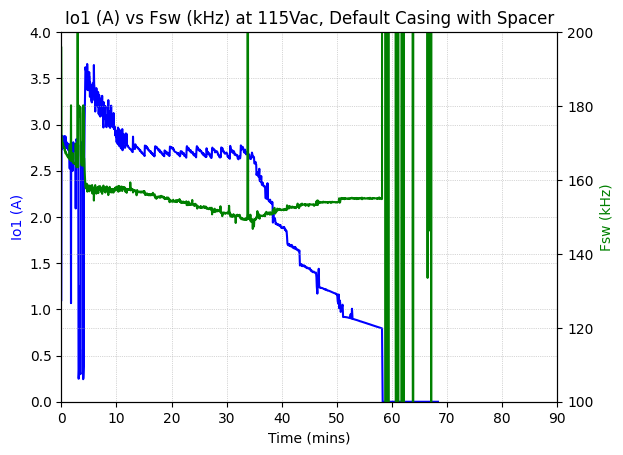

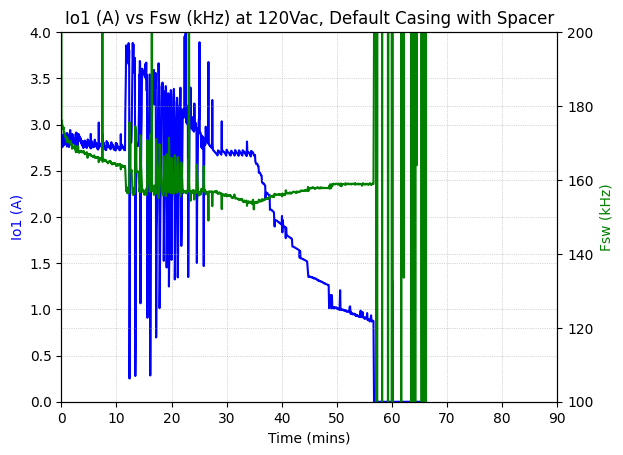

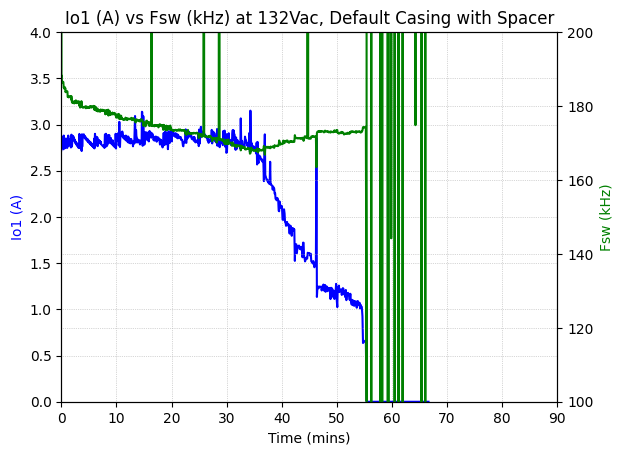

In [15]:
x_col = 'Time (mins)'
xmax = 90
xmin = 0

y_axis_plot_configs = [
    {
        'y_col_pri': 'Io1 (A)',
        'ymax_pri': 4,
        'ymin_pri': 0,
        'y_color_pri': 'blue',
        'y_col_sec': 'Vo (V)',
        'ymax_sec': 26,
        'ymin_sec': 18,
        'y_color_sec': 'red'
    },
    # {
    #     'y_col_pri': 'Io1 (A)',
    #     'ymax_pri': 4,
    #     'ymin_pri': 0,
    #     'y_color_pri': 'blue',
    #     'y_col_sec': 'Comms Status',
    #     'ymax_sec': 5,
    #     'ymin_sec': 0,
    #     'y_color_sec': 'brown'
    # },
    # {
    #     'y_col_pri': 'Fsw (kHz)',
    #     'ymax_pri': 200,
    #     'ymin_pri': 100,
    #     'y_color_pri': 'green',
    #     'y_col_sec': 'Comms Status',
    #     'ymax_sec': 5,
    #     'ymin_sec': 0,
    #     'y_color_sec': 'brown'
    # },
    {
        'y_col_pri': 'Io1 (A)',
        'ymax_pri': 4,
        'ymin_pri': 0,
        'y_color_pri': 'blue',
        'y_col_sec': 'Fsw (kHz)',
        'ymax_sec': 200,
        'ymin_sec': 100,
        'y_color_sec': 'green'
    },
    
    # {
    #     'y_col_pri': 'Icoil RMS',
    #     'ymax_pri': 0.7,
    #     'ymin_pri': 0.2,
    #     'y_color_pri': 'purple',
    #     'y_col_sec': 'Fsw (kHz)',
    #     'ymax_sec': 200,
    #     'ymin_sec': 100,
    #     'y_color_sec': 'green'
    # },
    # Add more dictionaries for additional sets of data
]

plot_data_for_fix_x_vs_ypri_and_ysec(dfs, selected_labels, x_col, xmax, xmin, y_axis_plot_configs)

In [11]:
def PLOT_DF_X_VS_YPRI(dfs, x_col, y_col, ymax, ymin, xmax, xmin, selected_labels=None):
    fig, ax1 = plt.subplots()

    for i, df in enumerate(dfs):
        name_list = selected_labels_ref
        label = name_list[i]
        
        if selected_labels is None or label in selected_labels:
            ax1.plot(df[x_col], df[y_col], label=label)
            ax1.set_xlabel(x_col)
            ax1.set_ylabel(y_col, color='black')
            
            ax1.grid(True, linestyle=':', linewidth=0.5)

            plt.title(f'{y_col}')
            
            # Set the labels and limits for the axes
            # ax1.legend(loc='upper right', prop={'size': 11})
            ax1.legend(loc='upper center', bbox_to_anchor=(0.5, -0.2), ncol=2)
            ax1.set_ylim(bottom=ymin, top=ymax)
            ax1.set_xlim(left=xmin, right=xmax)

    plt.show()

In [12]:
def PLOT_X_TO_MULTIPLE_Y_AXIS(excel_files_list,  xmax, xmin, x_col, ymax, ymin, y_col, selected_labels):
    """
        excel_files_list: list of excel files that contains the your data
        
        xmax: maximum x-axis limit on chart
        xmin: minimum x-axis limit on chart
        x_col: x-axis column reference

        ymax: maximum y-axis limit on chart
        ymin: minimum y-axis limit on chart
        y_col: y-axis column reference

        selected_labels: if only specific portion portion is selected, this is the filter

        Notes: dataframes is a global variable
    """
    dfs = [dataframes[file] for file in excel_files_list]
    
    ## PLOTTING GROUP PLOT
    PLOT_DF_X_VS_YPRI(dfs, x_col, y_col, ymax, ymin, xmax, xmin, selected_labels)
    
    ## PLOTTING INDIVIDUAL PLOTS
    for label in selected_labels:
        label_list = [label]
        PLOT_DF_X_VS_YPRI(dfs, x_col, y_col, ymax, ymin, xmax, xmin, label_list)

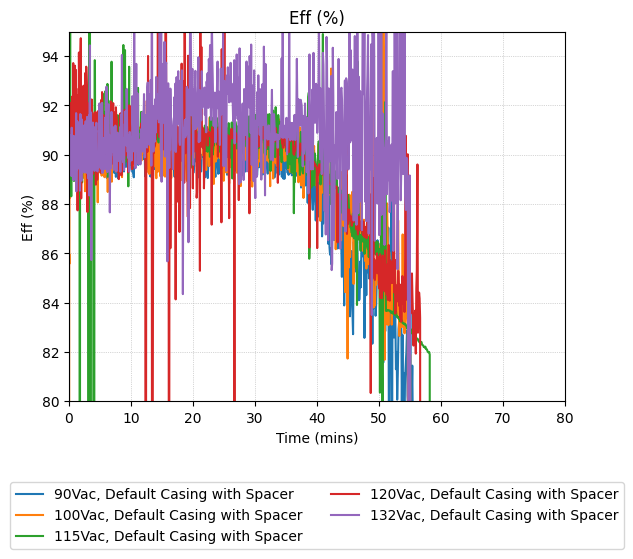

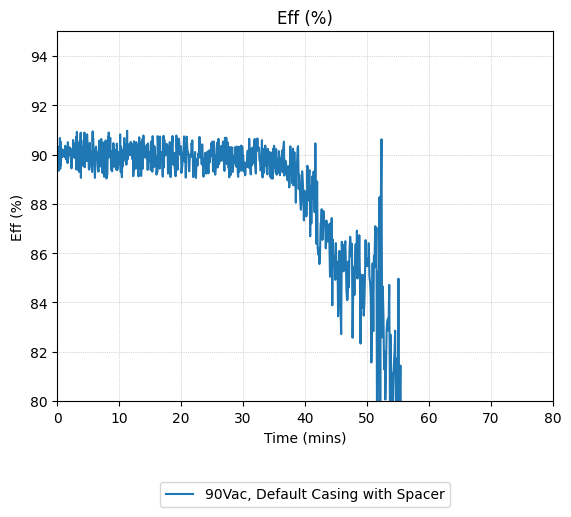

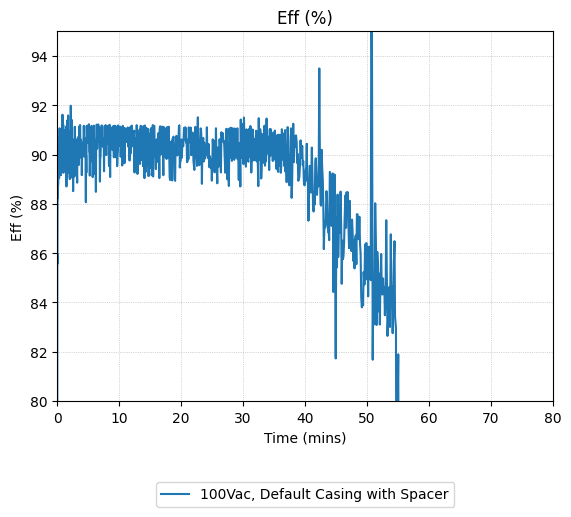

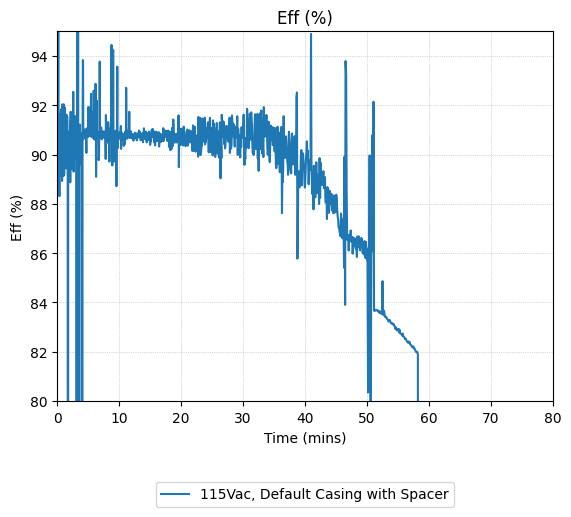

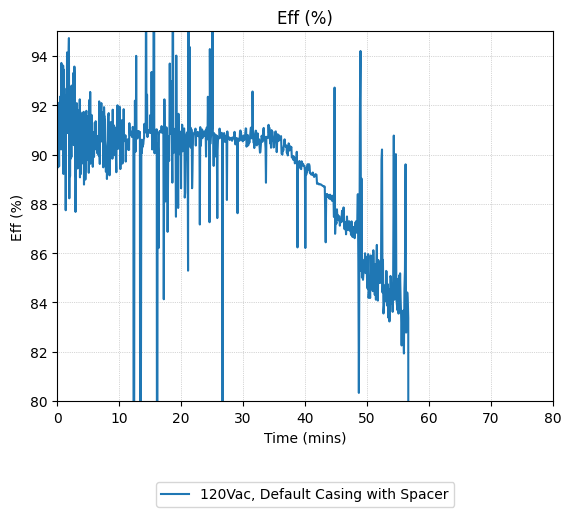

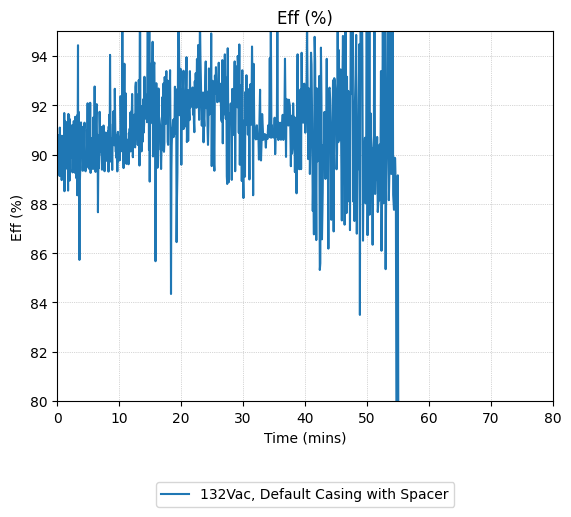

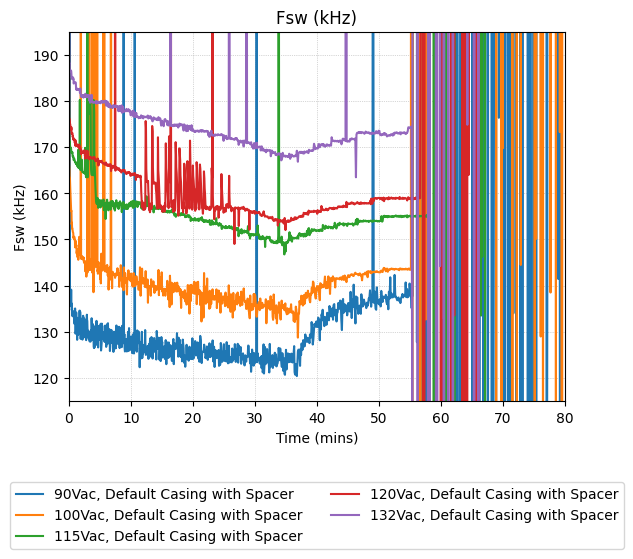

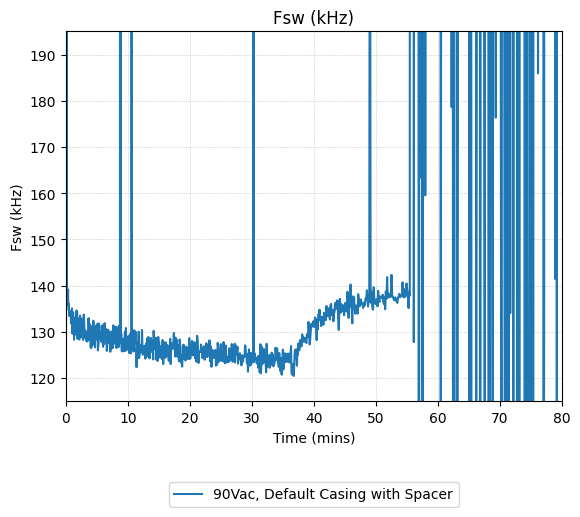

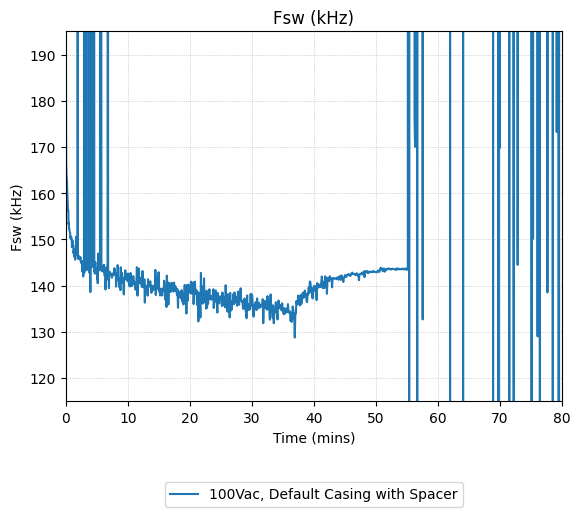

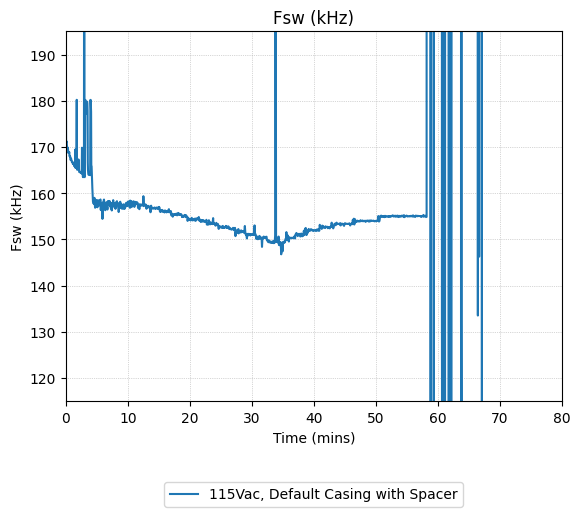

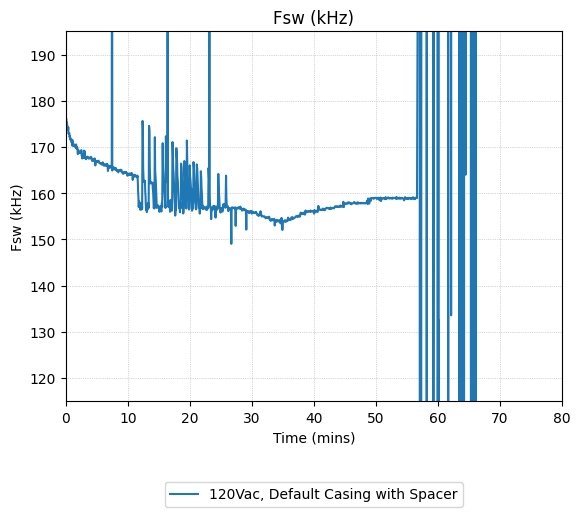

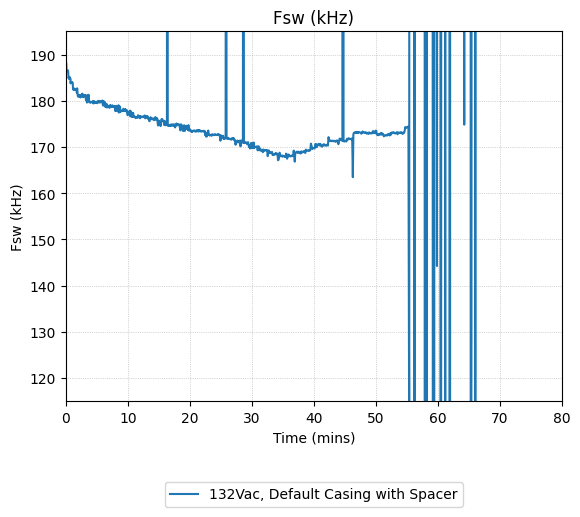

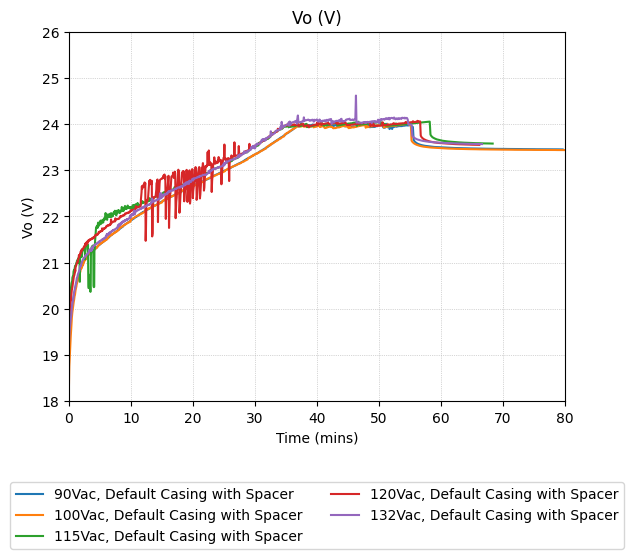

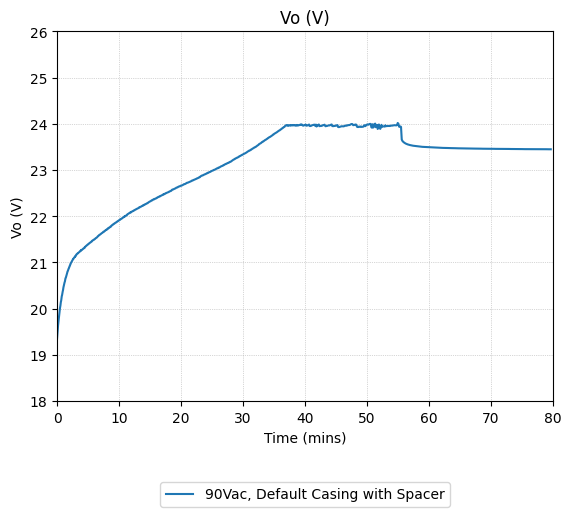

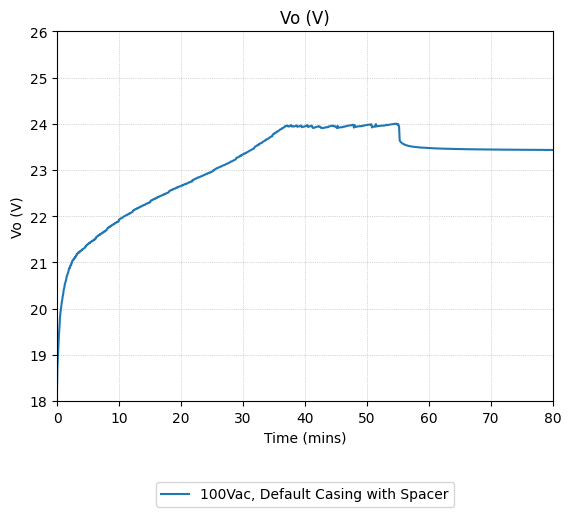

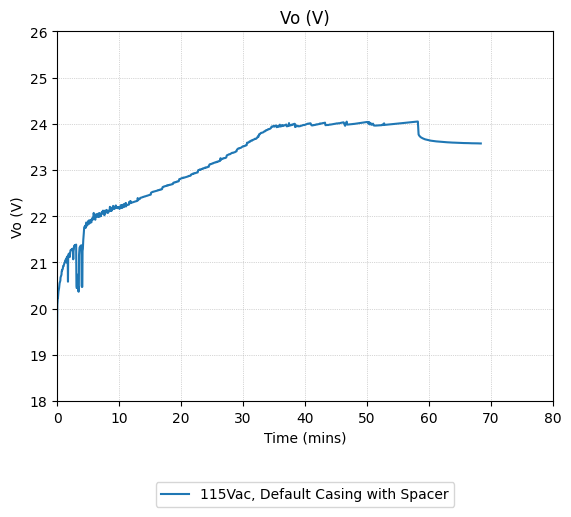

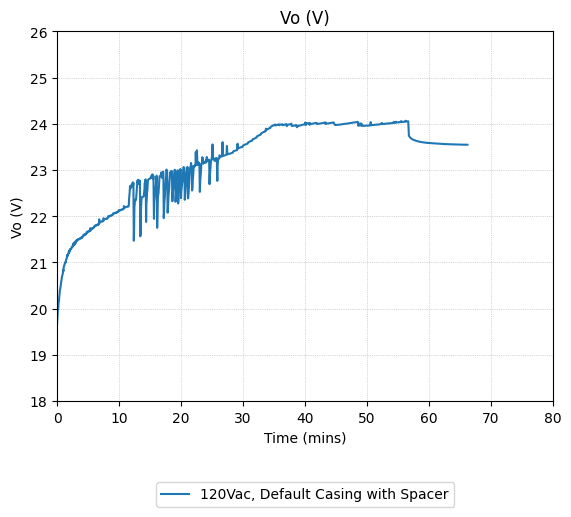

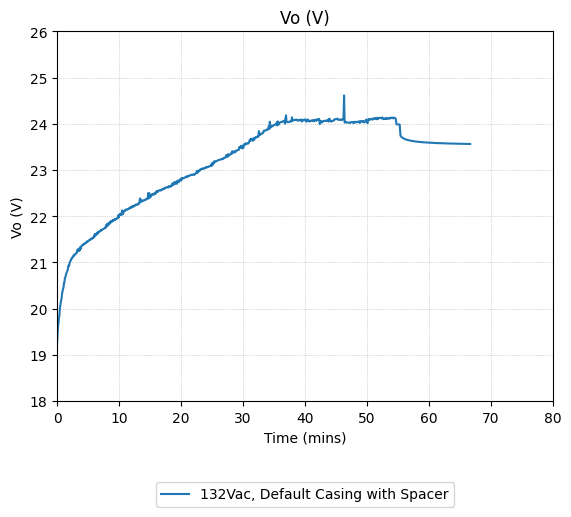

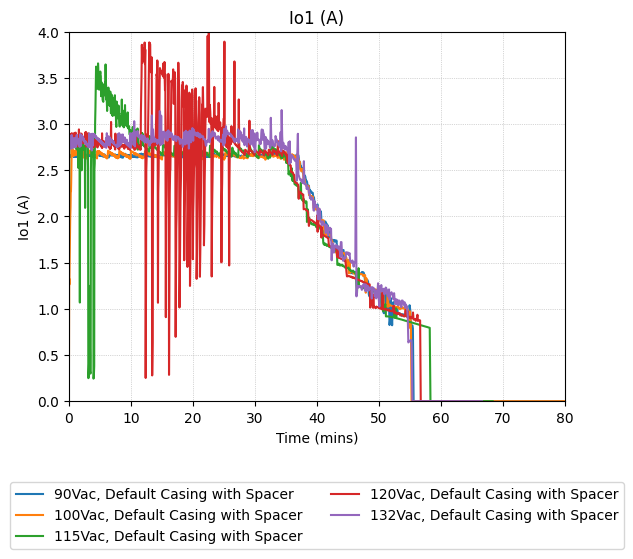

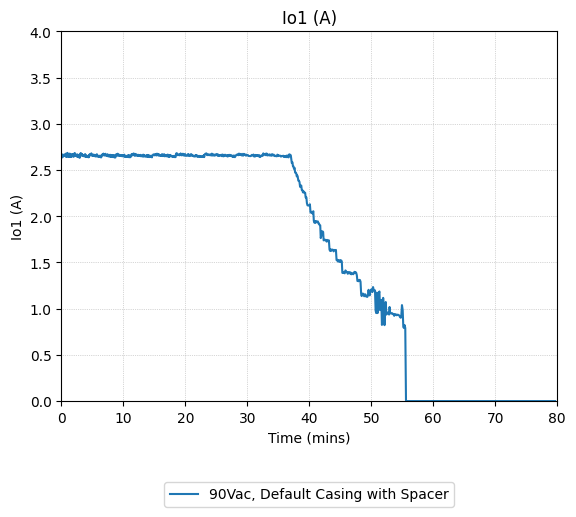

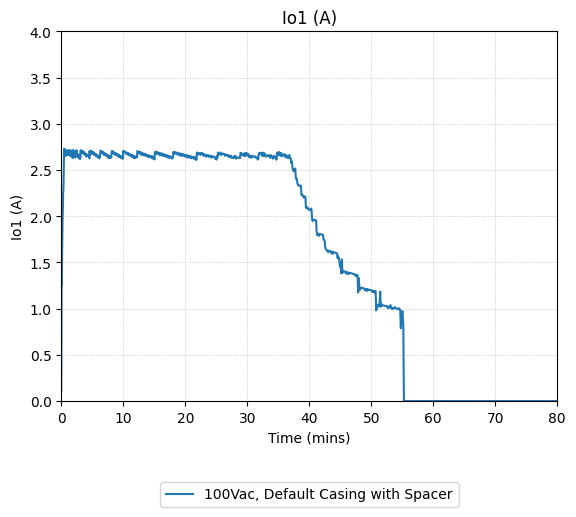

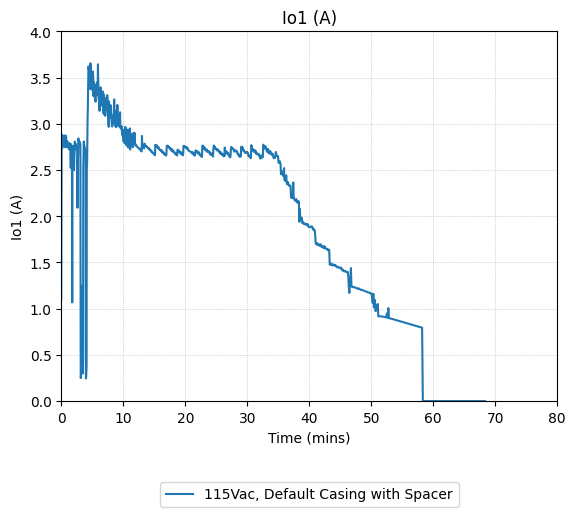

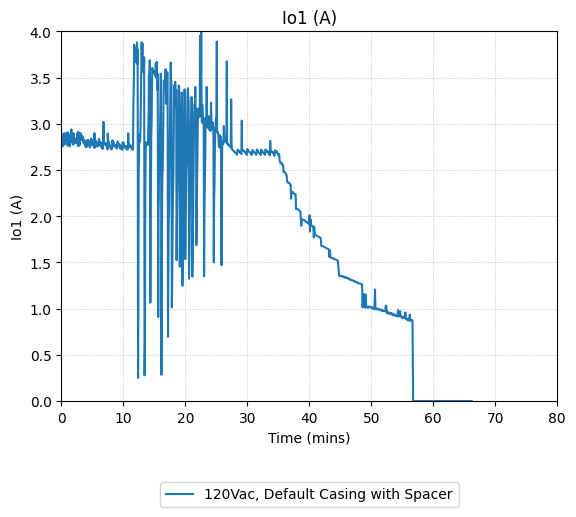

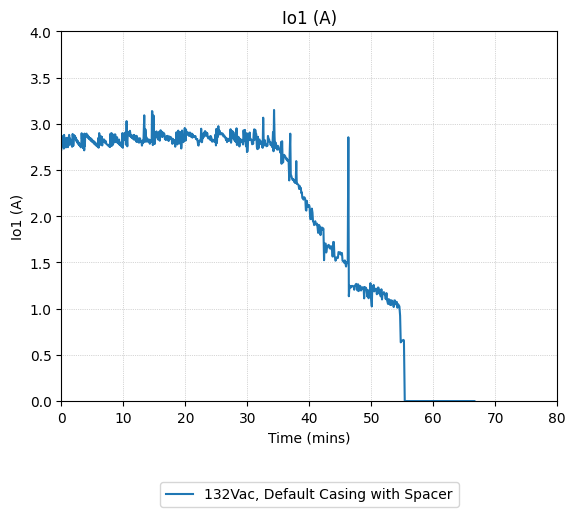

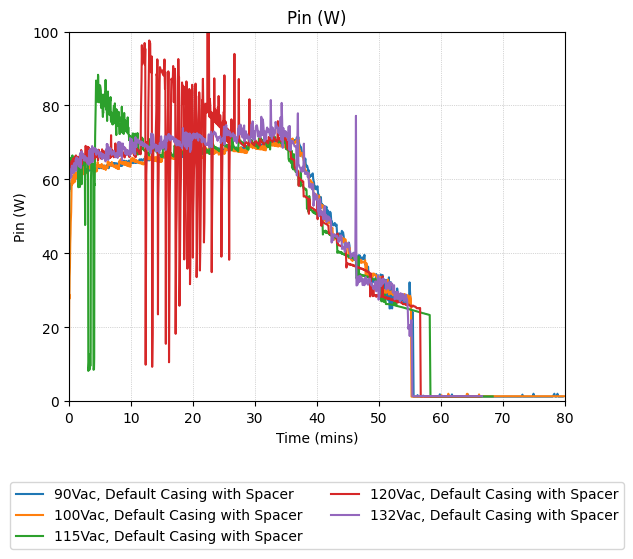

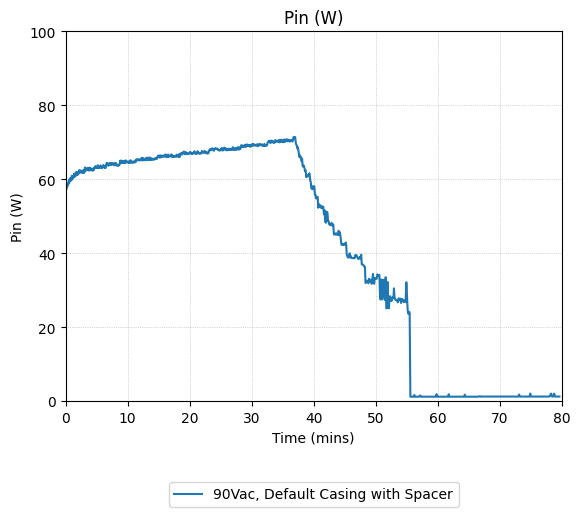

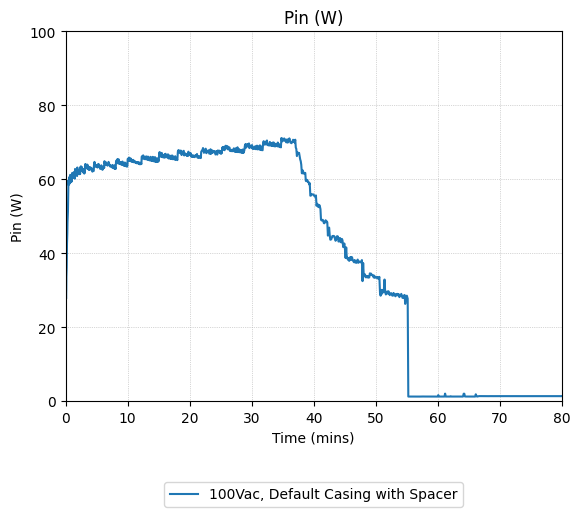

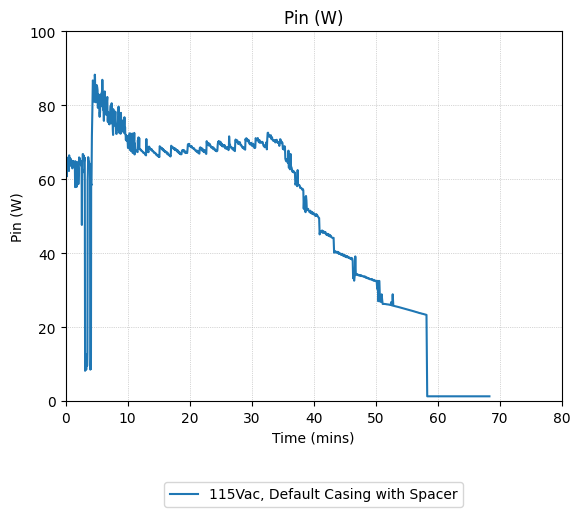

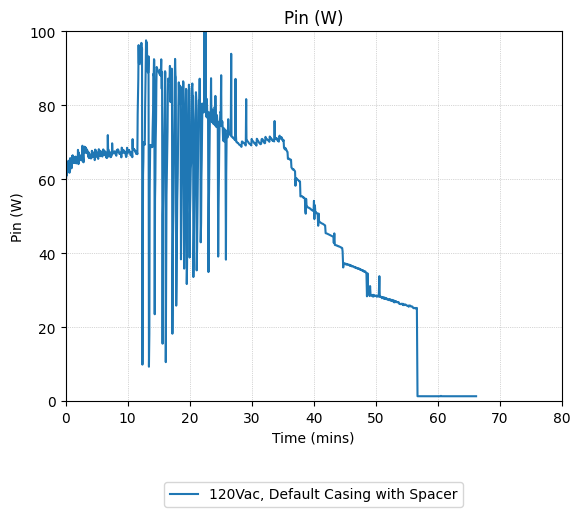

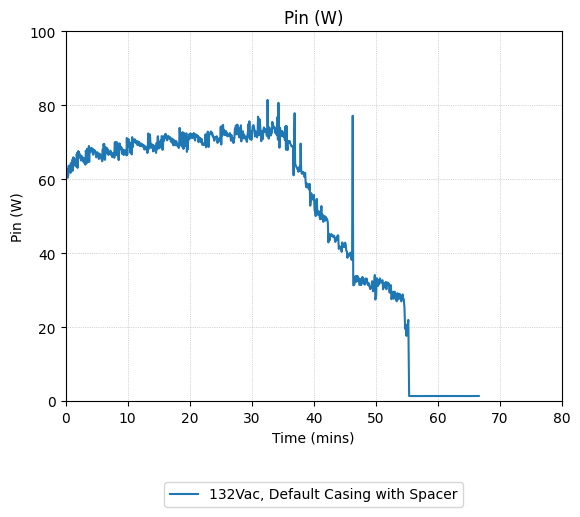

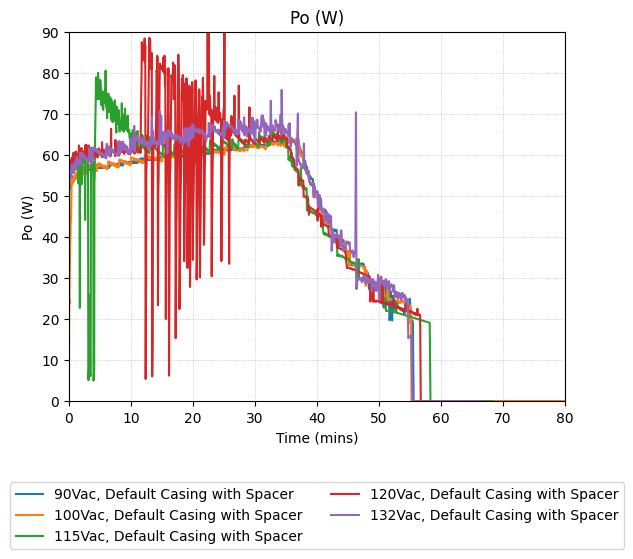

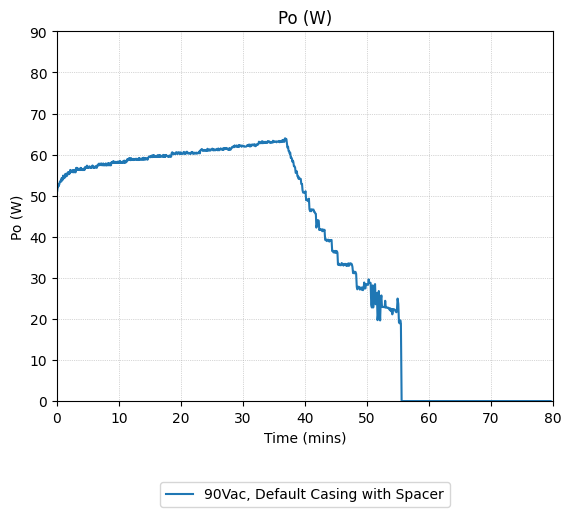

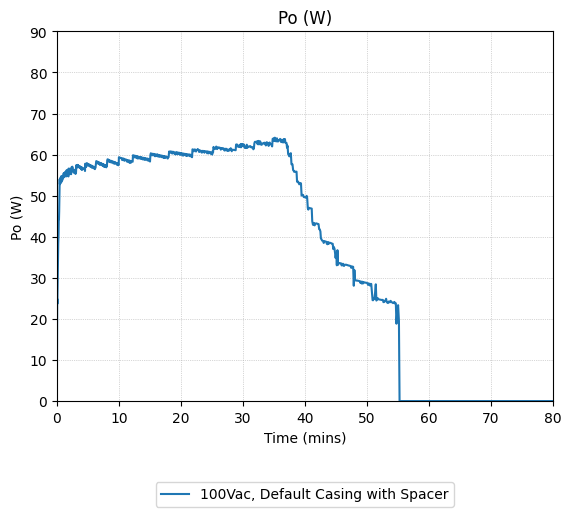

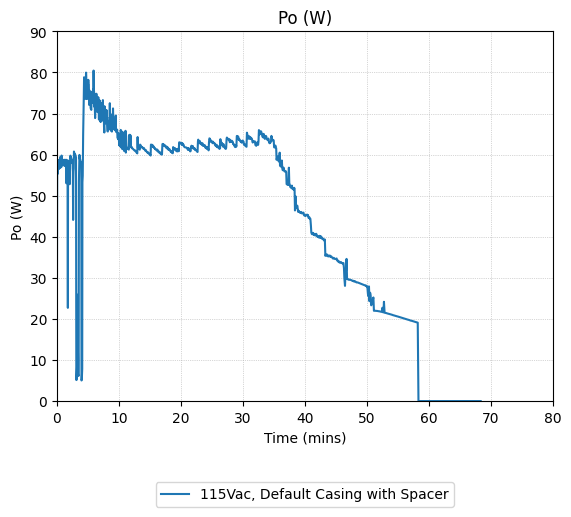

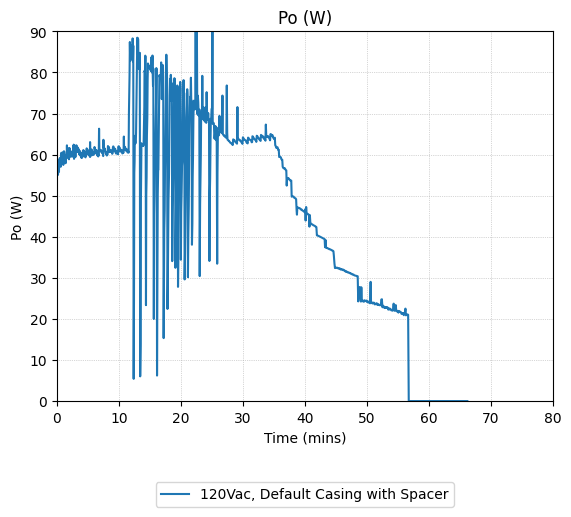

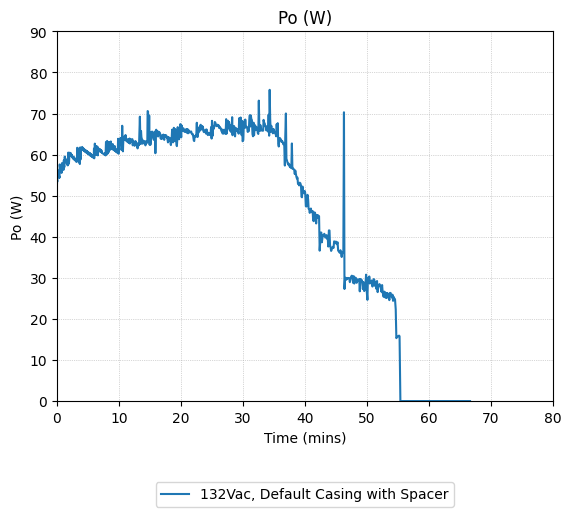

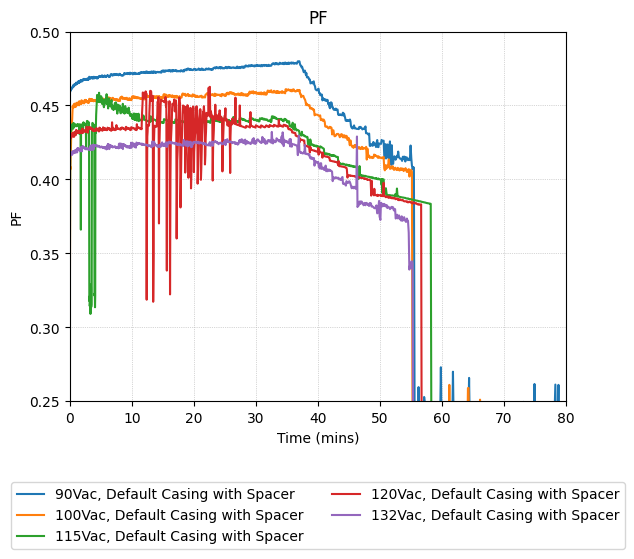

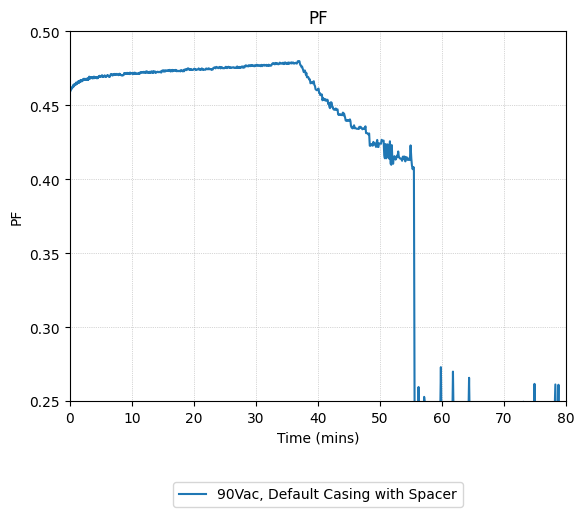

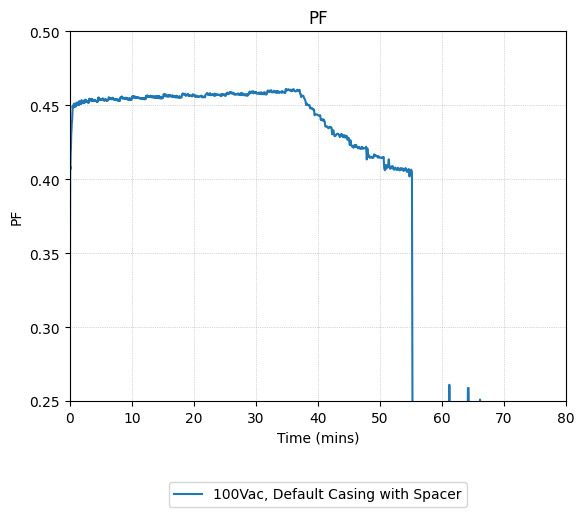

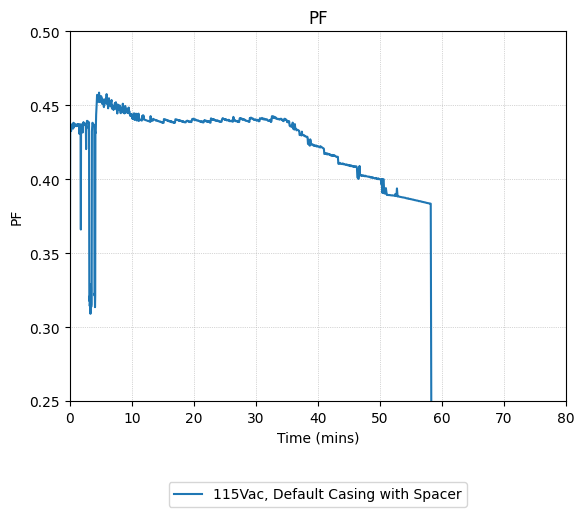

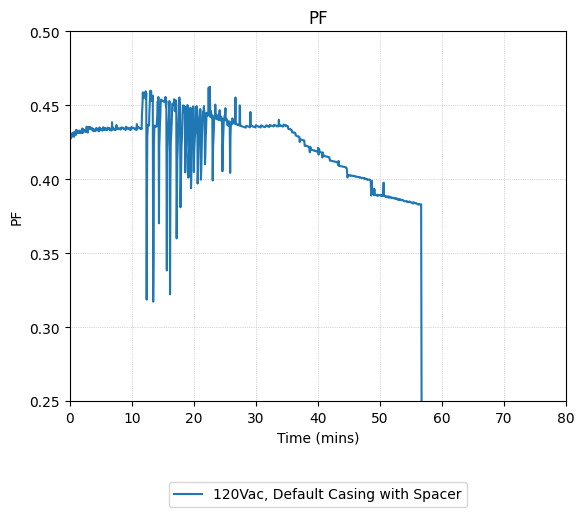

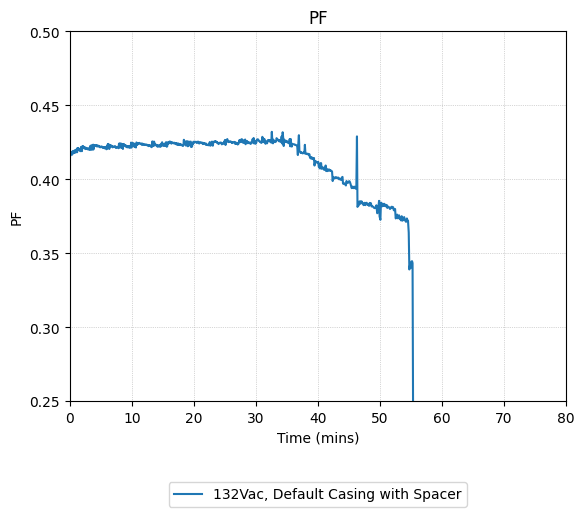

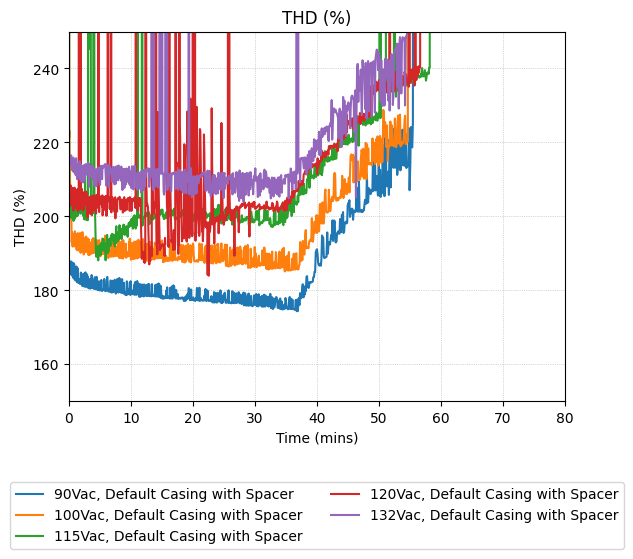

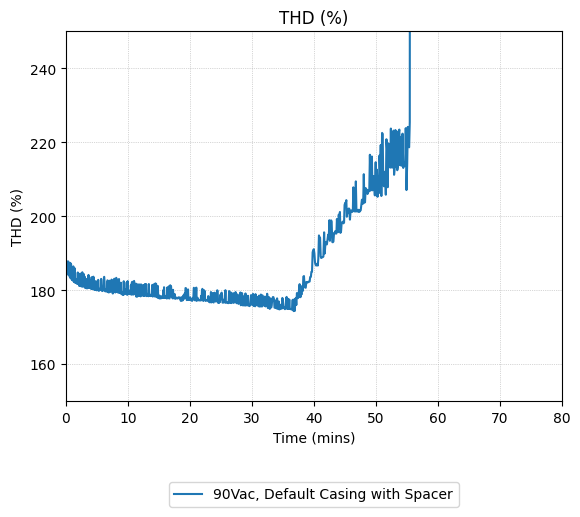

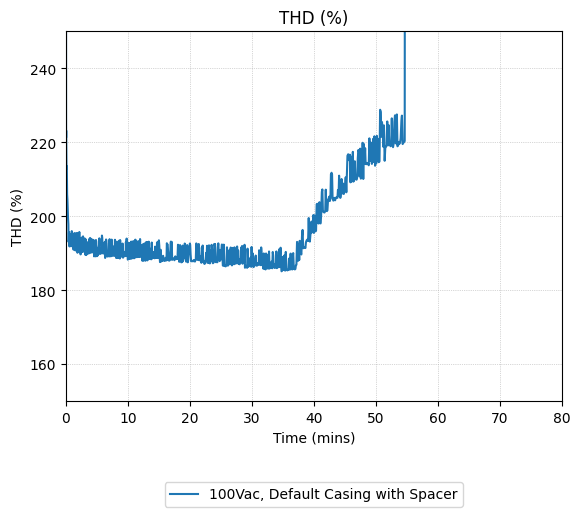

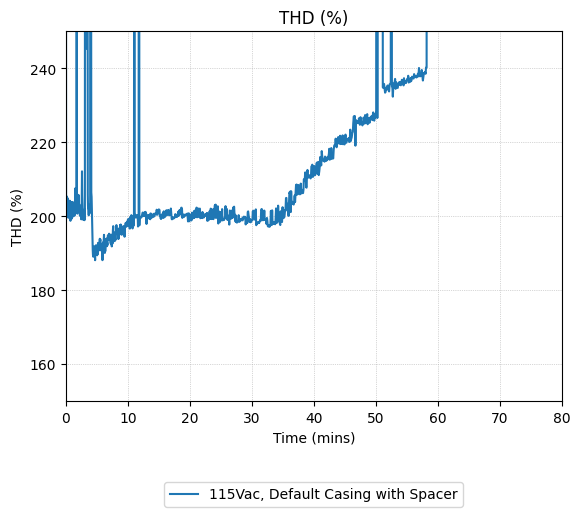

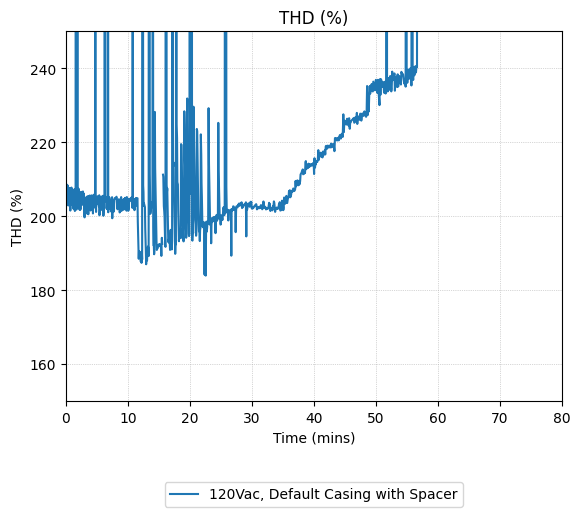

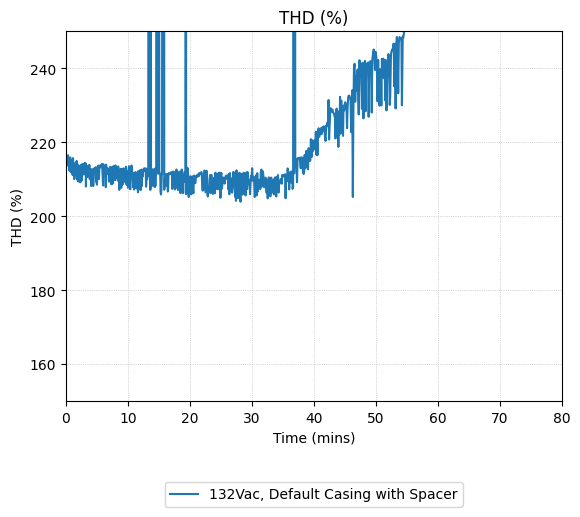

In [13]:
## FUNCTION USAGE OF "PLOT_X_TO_MULTIPLE_Y_AXIS"

xmax = 80
xmin = 0
x_col = 'Time (mins)'

data = [
    ( 'Eff (%)', (95, 80) ),
    ( 'Fsw (kHz)', (195, 115) ),
    ( 'Vo (V)', (26, 18) ),
    ( 'Io1 (A)', (4, 0) ),
    
    ( 'Pin (W)', (100, 0) ),
    ( 'Po (W)', (90, 0) ),
    ( 'PF', (0.5, 0.25) ),
    ( 'THD (%)', (250, 150) )
]

for y_col, (ymax, ymin) in data:
    PLOT_X_TO_MULTIPLE_Y_AXIS(excel_files_list, xmax, xmin, x_col, ymax, ymin, y_col, selected_labels=selected_labels_ref)